# Experiment 3: Enhanced Data Augmentation for Robust Ship Detection
## Objective

### The objective of this experiment is to improve the generalization ability of the U-Net model by introducing strong and diverse data augmentation techniques.

### Unlike Experiment 1 (baseline) and Experiment 2 (basic augmentation), this experiment focuses on:

* Simulating real-world SAR variations
* Making the model robust to:
    * Noise
    * Rotation
    * Scale changes
    * Intensity variations
* Reducing overfitting
* Improving Dice and IoU performance on validation data

# 1. Libraries & Dependencies

#### This section imports all required libraries for:
* Deep learning (PyTorch)
* Data handling
* Image processing
* Augmentation
* Visualization

In [2]:

# 1. Libraries & Dependencies


import os
import glob
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import numpy as np
import rasterio

import albumentations as A

import matplotlib.pyplot as plt


# 2. Configuration

#### Defines:
* Dataset paths
* Training parameters
* Device (GPU/CPU)
* Output directory

In [3]:

# 2. Configuration


config = {
    "data": {
        "root": "/dss/dsshome1/0F/di54cak/geo-oma-24/temesghen_ship_detection_notebook/data/Patches",
        "img_dir": "images",
        "mask_dir": "masks",
        "batch_size": 8,
        "num_workers": 2,
        "val_split": 0.2,
    },
    "training": {
        "epochs": 50,
        "lr": 1e-3,
        "device": "cuda" if torch.cuda.is_available() else "cpu",
    },
    "outputs": {
        "save_dir": "outputs"
    }
}

os.makedirs(config["outputs"]["save_dir"], exist_ok=True)

device = config["training"]["device"]
print("Using device:", device)


Using device: cpu


# 3. Dataset Class

#### Handles:

* Reading SAR images (VV + VH)
* Clipping & normalization
* Mask loading
* Applying augmentations
* Converting to tensors

In [4]:

# 3. Dataset Class


class ShipDataset(Dataset):

    def __init__(self, img_paths, mask_paths, transform=None):
        self.img_paths = img_paths
        self.mask_paths = mask_paths
        self.transform = transform

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):

        # Read SAR image
        with rasterio.open(self.img_paths[idx]) as src:

            vv = src.read(1).astype(np.float32)
            vh = src.read(2).astype(np.float32)

            img = np.stack([vv, vh], axis=-1)

            # clipping
            img = np.clip(img, -25, 10)

            # normalization
            img = (img + 25.0) / 35.0

        # Read mask
        with rasterio.open(self.mask_paths[idx]) as src:

            mask = src.read(1).astype(np.float32)

            if mask.max() > 0:
                mask = mask / mask.max()

            mask = np.expand_dims(mask, -1)

        # Augmentation
        if self.transform:

            aug = self.transform(image=img, mask=mask)

            img = aug["image"]
            mask = aug["mask"]

        # Convert to tensor
        img = torch.from_numpy(img).permute(2,0,1).float()
        mask = torch.from_numpy(mask).permute(2,0,1).float()

        return img, mask


# 4. Data Augmentation (Key Improvement)

#### This is the main contribution of Experiment 3.
#### Enhancements include:
* Geometric transformations
* Noise simulation (important for SAR)
* Blur (sensor imperfections)
* Brightness/contrast variations

In [5]:

# 4. Data Augmentation


train_tf = A.Compose([

    # geometric transformations
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),

    A.Rotate(limit=30, p=0.5),

    A.ShiftScaleRotate(
        shift_limit=0.05,
        scale_limit=0.1,
        rotate_limit=20,
        p=0.5
    ),

    # SAR intensity variations
    A.RandomBrightnessContrast(
        brightness_limit=0.15,
        contrast_limit=0.15,
        p=0.4
    ),

    # simulate SAR noise
    A.GaussNoise(
        var_limit=(5.0,20.0),
        p=0.3
    ),

    # slight blur
    A.GaussianBlur(
        blur_limit=(3,5),
        p=0.2
    )

])


/dss/dsshome1/0F/di54cak/geo-oma-24/.venv/lib64/python3.12/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/dss/dsstbyfs02/scratch/0F/di54cak/di54cak/tmp.T5NVv8pNYM/ipykernel_93957/3948465000.py:27: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(


# 5. Dataloaders

#### Splits dataset into train/validation
#### Applies augmentation only to training data

In [6]:

# 5. Dataloaders

def get_dataloaders(cfg):

    img_dir = os.path.join(cfg["data"]["root"], cfg["data"]["img_dir"])
    mask_dir = os.path.join(cfg["data"]["root"], cfg["data"]["mask_dir"])

    imgs = sorted(glob.glob(os.path.join(img_dir, "*.tif")))
    masks = sorted(glob.glob(os.path.join(mask_dir, "*.tif")))

    split = int((1 - cfg["data"]["val_split"]) * len(imgs))

    train_imgs = imgs[:split]
    val_imgs = imgs[split:]

    train_masks = masks[:split]
    val_masks = masks[split:]

    train_ds = ShipDataset(train_imgs, train_masks, train_tf)
    val_ds = ShipDataset(val_imgs, val_masks, None)

    train_loader = DataLoader(
        train_ds,
        batch_size=cfg["data"]["batch_size"],
        shuffle=True
    )

    val_loader = DataLoader(
        val_ds,
        batch_size=cfg["data"]["batch_size"],
        shuffle=False
    )

    return train_loader, val_loader


train_loader, val_loader = get_dataloaders(config)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))


Train batches: 50
Val batches: 13


# 6. U-Net Model

#### Standard U-Net architecture for segmentation:

* Encoder–decoder structure
* Skip connections
* Binary mask output

In [7]:

# 6. U-Net Model


class DoubleConv(nn.Module):

    def __init__(self, in_c, out_c):

        super().__init__()

        self.net = nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_c, out_c, 3, padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.net(x)


class UNet(nn.Module):

    def __init__(self, in_channels=2, base=32):

        super().__init__()

        self.enc1 = DoubleConv(in_channels, base)
        self.enc2 = DoubleConv(base, base*2)
        self.enc3 = DoubleConv(base*2, base*4)

        self.pool = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(base*4, base*8)

        self.up1 = nn.ConvTranspose2d(base*8, base*4, 2,2)
        self.dec1 = DoubleConv(base*8, base*4)

        self.up2 = nn.ConvTranspose2d(base*4, base*2, 2,2)
        self.dec2 = DoubleConv(base*4, base*2)

        self.up3 = nn.ConvTranspose2d(base*2, base, 2,2)
        self.dec3 = DoubleConv(base*2, base)

        self.out = nn.Conv2d(base,1,1)

    def forward(self, x):

        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))

        b = self.bottleneck(self.pool(e3))

        u1 = self.up1(b)
        d1 = self.dec1(torch.cat([u1,e3], dim=1))

        u2 = self.up2(d1)
        d2 = self.dec2(torch.cat([u2,e2], dim=1))

        u3 = self.up3(d2)
        d3 = self.dec3(torch.cat([u3,e1], dim=1))

        return torch.sigmoid(self.out(d3))


model = UNet(in_channels=2).to(device)


# 7. Loss & Metrics

#### Used to evaluate segmentation performance:

* BCE Loss for pixel-wise error
* Dice for overlap quality
* IoU for region similarity

In [8]:

# 7. Loss & Metrics


bce = nn.BCELoss()

def dice_coef(pred, target, smooth=1e-6):

    pred = (pred > 0.5).float()

    inter = (pred * target).sum()

    return (2*inter + smooth) / (pred.sum() + target.sum() + smooth)


def iou_score(pred, target, smooth=1e-6):

    pred = (pred > 0.5).float()

    inter = (pred * target).sum()

    union = pred.sum() + target.sum() - inter

    return (inter + smooth) / (union + smooth)


# 8. Training Loop

#### Performs forward + backward pass
#### Tracks metrics
#### Evaluates on validation set

In [9]:

# 8. Training Loop


optimizer = optim.Adam(model.parameters(), lr=config["training"]["lr"])

train_loss_hist = []
val_loss_hist = []

train_dice_hist = []
val_dice_hist = []

train_iou_hist = []
val_iou_hist = []

for epoch in range(config["training"]["epochs"]):

    model.train()

    tl, td, ti = 0,0,0

    for img, mask in train_loader:

        img = img.to(device)
        mask = mask.to(device)

        pred = model(img)

        loss = bce(pred, mask)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        tl += loss.item()
        td += dice_coef(pred, mask).item()
        ti += iou_score(pred, mask).item()

    model.eval()

    vl, vd, vi = 0,0,0

    with torch.no_grad():

        for img, mask in val_loader:

            img = img.to(device)
            mask = mask.to(device)

            pred = model(img)

            loss = bce(pred, mask)

            vl += loss.item()
            vd += dice_coef(pred, mask).item()
            vi += iou_score(pred, mask).item()

    train_loss_hist.append(tl/len(train_loader))
    val_loss_hist.append(vl/len(val_loader))

    train_dice_hist.append(td/len(train_loader))
    val_dice_hist.append(vd/len(val_loader))

    train_iou_hist.append(ti/len(train_loader))
    val_iou_hist.append(vi/len(val_loader))

    print(f"Epoch {epoch+1}: "
          f"Train Loss={train_loss_hist[-1]:.4f}, "
          f"Val Loss={val_loss_hist[-1]:.4f}, "
          f"Train Dice={train_dice_hist[-1]:.4f}, "
          f"Val Dice={val_dice_hist[-1]:.4f}, "
          f"Train IoU={train_iou_hist[-1]:.4f}, "
          f"Val IoU={val_iou_hist[-1]:.4f}")


Epoch 1: Train Loss=0.3673, Val Loss=0.2112, Train Dice=0.1235, Val Dice=0.0000, Train IoU=0.0710, Val IoU=0.0000
Epoch 2: Train Loss=0.1944, Val Loss=0.1509, Train Dice=0.0151, Val Dice=0.2023, Train IoU=0.0082, Val IoU=0.1142
Epoch 3: Train Loss=0.1239, Val Loss=0.0926, Train Dice=0.0110, Val Dice=0.0000, Train IoU=0.0058, Val IoU=0.0000
Epoch 4: Train Loss=0.0892, Val Loss=0.0620, Train Dice=0.0001, Val Dice=0.0004, Train IoU=0.0001, Val IoU=0.0002
Epoch 5: Train Loss=0.0716, Val Loss=0.0562, Train Dice=0.0031, Val Dice=0.0000, Train IoU=0.0016, Val IoU=0.0000
Epoch 6: Train Loss=0.0617, Val Loss=0.0407, Train Dice=0.0049, Val Dice=0.1504, Train IoU=0.0025, Val IoU=0.0820
Epoch 7: Train Loss=0.0560, Val Loss=0.0497, Train Dice=0.0217, Val Dice=0.0052, Train IoU=0.0117, Val IoU=0.0027
Epoch 8: Train Loss=0.0523, Val Loss=0.0319, Train Dice=0.1337, Val Dice=0.6010, Train IoU=0.0757, Val IoU=0.4398
Epoch 9: Train Loss=0.0504, Val Loss=0.0280, Train Dice=0.1775, Val Dice=0.6319, Train I

# 9. Training Curves

#### Visualizes:

* Loss convergence
* Dice improvement
* IoU improvement

#### Helps detect:

* Overfitting
* Underfitting

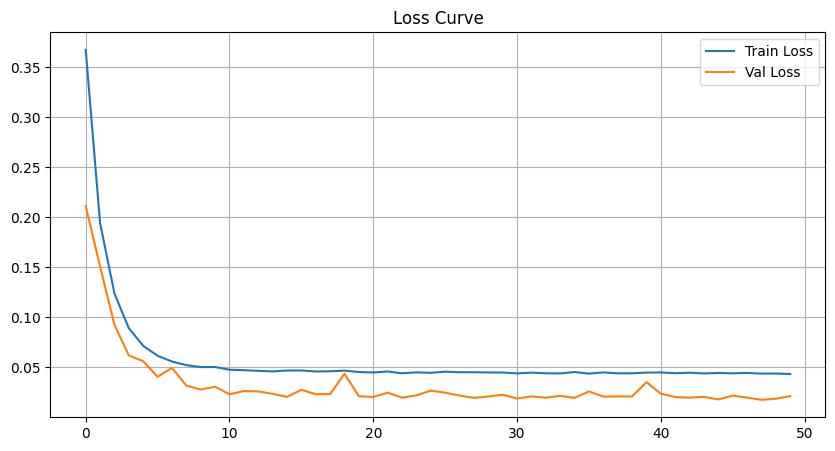

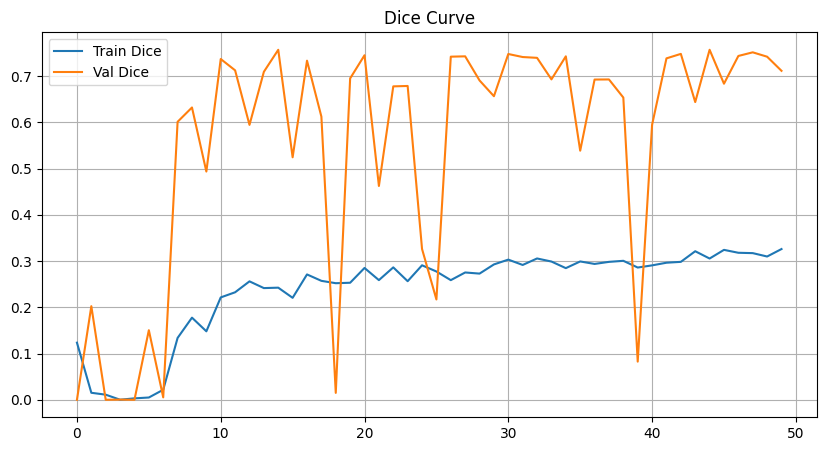

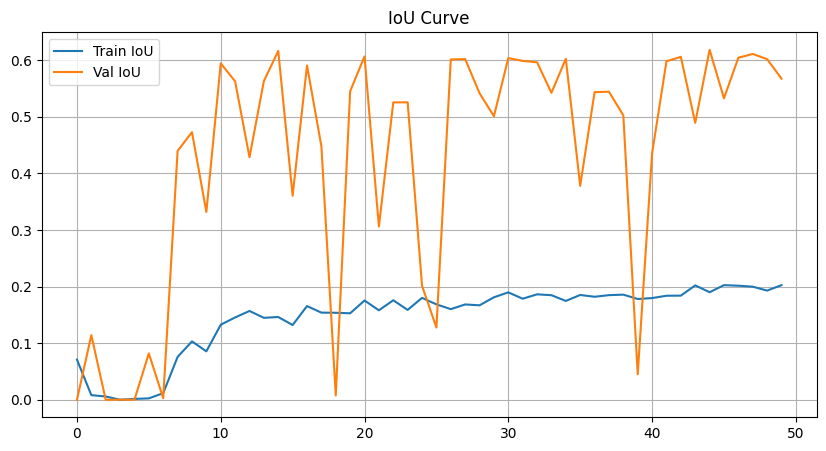

In [10]:

# 9. Plot Training Curves


plt.figure(figsize=(10,5))
plt.plot(train_loss_hist,label="Train Loss")
plt.plot(val_loss_hist,label="Val Loss")
plt.legend()
plt.grid(True)
plt.title("Loss Curve")
plt.show()


plt.figure(figsize=(10,5))
plt.plot(train_dice_hist,label="Train Dice")
plt.plot(val_dice_hist,label="Val Dice")
plt.legend()
plt.grid(True)
plt.title("Dice Curve")
plt.show()


plt.figure(figsize=(10,5))
plt.plot(train_iou_hist,label="Train IoU")
plt.plot(val_iou_hist,label="Val IoU")
plt.legend()
plt.grid(True)
plt.title("IoU Curve")
plt.show()


# 10. Prediction Visualization

#### Shows:
* Input channels (VV, VH)
* Ground truth mask
* Predicted mask

#### Useful for qualitative evaluation.

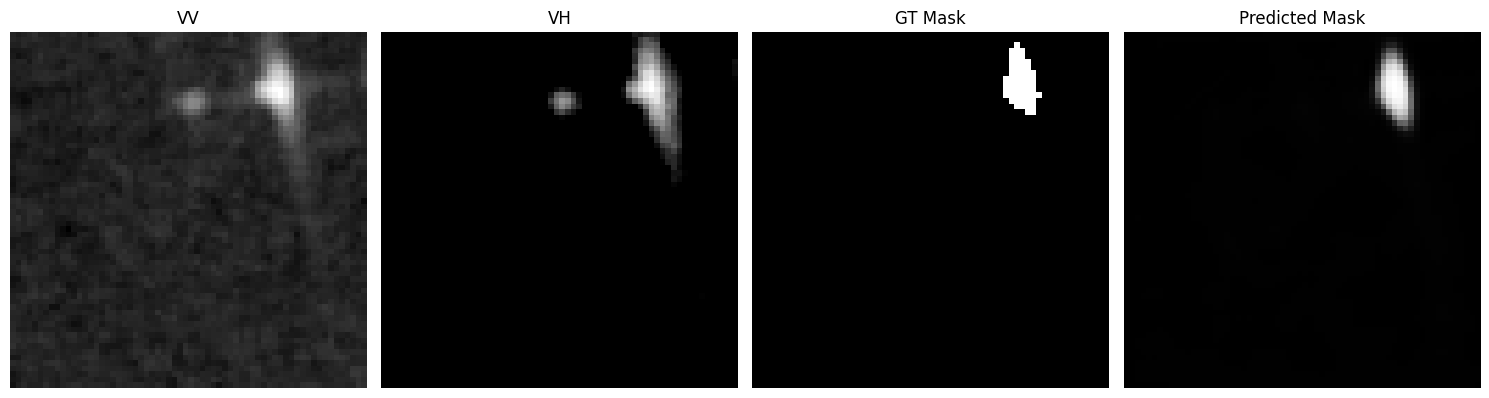

In [11]:

# 10. Visualize Predictions

img, mask = next(iter(val_loader))

img = img.to(device)
mask = mask.to(device)

with torch.no_grad():

    pred = model(img)

img = img.cpu()
mask = mask.cpu()
pred = pred.cpu()

fig, axs = plt.subplots(1,4, figsize=(15,5))

axs[0].imshow(img[0,0], cmap="gray")
axs[0].set_title("VV")

axs[1].imshow(img[0,1], cmap="gray")
axs[1].set_title("VH")

axs[2].imshow(mask[0,0], cmap="gray")
axs[2].set_title("GT Mask")

axs[3].imshow(pred[0,0], cmap="gray")
axs[3].set_title("Predicted Mask")

for ax in axs:
    ax.axis("off")

plt.tight_layout()
plt.show()
